In [1]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sb

In [3]:
df = pd.read_csv('file.csv')

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

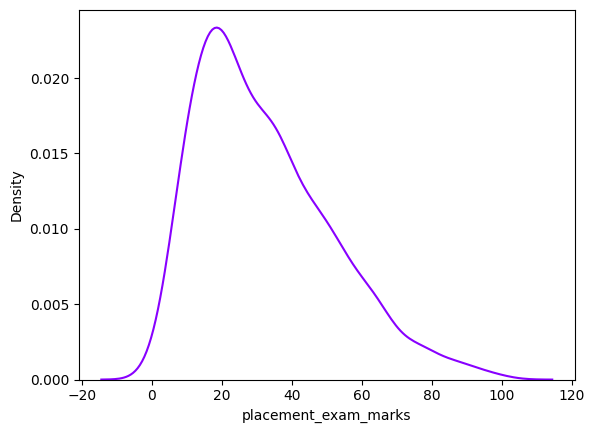

In [4]:
sb.kdeplot(data=df['placement_exam_marks'], color="#8800ff")

In [ ]:
(df['placement_exam_marks'].skew() * 100).__round__(3)

np.float64(83.564)

In [9]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


### **Boxplot of data**

<Axes: xlabel='placement_exam_marks'>

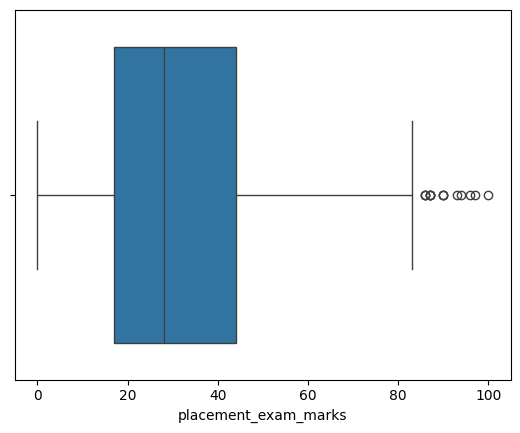

In [12]:
sb.boxplot(data=df, x='placement_exam_marks')

### **Implementing IQR method**

In [15]:
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)

print(f'''Q1 = {Q1}
Q3 = {Q3}''')

Q1 = 17.0
Q3 = 44.0


In [16]:
IQR = Q3 - Q1

In [17]:
IQR

np.float64(27.0)

In [18]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

### **Outliers**

In [19]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


### **Trimming**

In [20]:
df_trimmed = df[df['placement_exam_marks'] < upper_limit]

In [21]:
df_trimmed.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

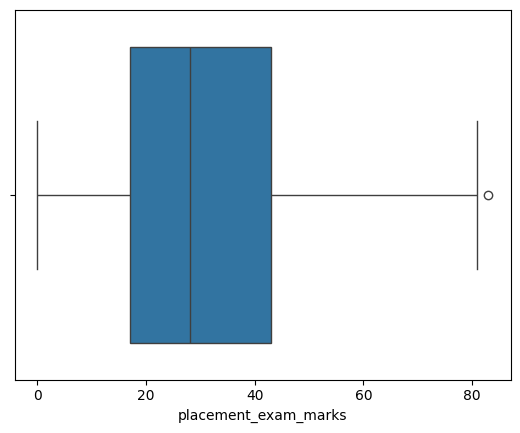

In [22]:
sb.boxplot(data=df_trimmed, x='placement_exam_marks')

### **Capping**

In [23]:
df_capped = df.copy()

df_capped['placement_exam_marks'] = np.where(
    df_capped['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        df_capped['placement_exam_marks'] < lower_limit,
        lower_limit,
        df_capped['placement_exam_marks']
    )
)

### **Results**

<Axes: xlabel='placement_exam_marks'>

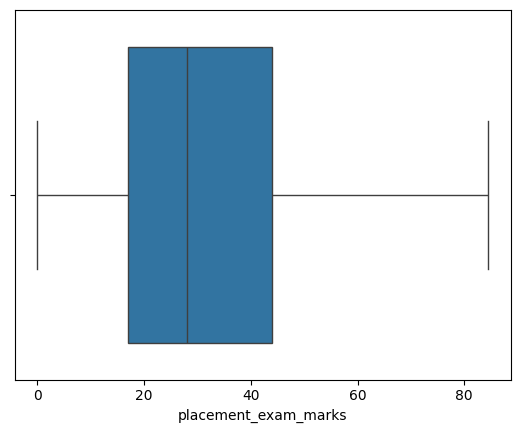

In [24]:
sb.boxplot(data=df_capped, x='placement_exam_marks')